# Intro

The motivation behind this notebook is to do an EDA of the data that we joined together in the previous notebook (add_station_information_together). We want to get a handle of how much missing data there is, as well as checking correlations and seeing what variables seem to be most important to demand.

## Libraries

In [1]:
import polars as pl
import matplotlib.pyplot as plt

## Data read in
This is using polars for example

In [2]:
cabi = pl.read_parquet("C:/Users/bingo/OneDrive - Georgia Institute of Technology/CSE7643/project/cabi_demand_with_stations.parquet")

# Description and cleaning

In [3]:
cabi.describe()

statistic,start_station_id,started_at_15,deps,arrs,demand,station_name,latitude,longitude,TRACTCE_left,GEOID_left,m1_1_schoo,m1_2_quali,m1_3_playg,m1_4_cross,m1_5_safe_,m1_6_libra,m1_7_wirel,m1_8_broad,m1_9_recre,m2_1_commu,m3_1_banks,m3_2_check,m4_1_quali,m4_2_share,m4_3_affor,m4_4_vacan,m5_1_buses,m5_2_metro,m5_3_capit,m5_4_bike_,m5_5_sidew,m5_6_parki,m6_1_groce,m6_2_low_f,m6_3_farme,m6_4_healt,…,d1_raw,d2_raw,d3_raw,d4_raw,d5_raw,d6_raw,d7_raw,d8_raw,d9_raw,STATEFP,COUNTYFP,TRACTCE_right,GEOIDFQ,GEOID_right,NAME.x,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,NAME.y,total_popE,total_popM,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,year,state,in_low_stress_bikeshed,in_total_bikeshed
str,f64,str,f64,f64,f64,str,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64
"""count""",1.8621391e7,"""18765877""",1.1972513e7,1.1845721e7,5.052357e6,"""18621383""",1.8621383e7,1.8621383e7,"""15456250""","""15456250""",1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,…,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,"""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""",1.8621383e7,1.8621383e7,"""18621383""",1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.7790103e7,1.7790103e7,1.7603386e7,1.7431449e7,1.8621383e7,"""18621383""",1.8621383e7,1.8621383e7
"""null_count""",144486.0,"""0""",6.793364e6,6.920156e6,1.371352e7,"""144494""",144494.0,144494.0,"""3309627""","""3309627""",3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,…,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,3.309627e6,"""144494""","""144494""","""144494""","""144494""","""144494""","""144494""","""144494""","""144494""","""144494""","""144494""","""144494""",144494.0,144494.0,"""144494""",144494.0,144494.0,144494.0,144494.0,144494.0,144494.0,975774.0,975774.0,1.162491e6,1.334428e6,144494.0,"""144494""",144494.0,144494.0
"""mean""",31406.154648,"""2024-04-11 16:50:21.997996+00:…",1.814152,1.83357,0.011093,null,38.903591,-77.034744,null,null,0.979661,0.574791,0.614376,0.121428,0.195709,0.810981,0.975289,0.914722,0.902728,0.831588,0.978337,0.053236,0.330815,0.450211,0.09541,0.554641,0.657605,0.872678,0.880767,0.155179,0.982497,0.928139,0.933204,0.650249,0.861223,0.565369,…,0.532328,0.657616,0.471761,0.576942,0.595971,0.534208,0.572031,0.476392,0.560046,null,null,null,null,null,null,null,null,null,null,null,870288.276693,227458.289452,null,3160.266509,467.246182,1529.71012,297.80524,1630.556389,323.90588,35.154061,3.240575,134903.168291,33066.755768,2024.0,null,0.95035,0.992544
"""std""",332.00315,null,4.153978,4.31171,1.975196,null,0.030651,0.040627,null,null,0.069254,0.39618,0.388497,0.148115,0.330364,0.285424,0.081095,0.102029,0.212511,0.140561,0.070136,0.144801,0.221501,0.282813,0.148669,0.308904,0.213376,0.266496,0.20832,0.100408,0.018072,0.033291,0.17036,0.305912,0.264105,0.45221,…,0.171242,0.272677,0.078406,0.176672,0.136406,0.167604,0.259203,0.099084,0.137873,null,null,null,null,null,null,null,null,null,null,null,1.3233e6,974263.496184,null,1401.853708,198.237465,681.870369,126.215877,774.688154,143.10396

Lets clean this data up

In [4]:
cabi = cabi.with_columns([
    pl.col("deps").fill_null(0),
    pl.col("arrs").fill_null(0),
]).with_columns(
    (pl.col("arrs") - pl.col("deps")).alias("demand")
).filter(pl.col("start_station_id").is_not_null()) # filter out null stations

In [5]:
cabi.describe()  # check again

statistic,start_station_id,started_at_15,deps,arrs,demand,station_name,latitude,longitude,TRACTCE_left,GEOID_left,m1_1_schoo,m1_2_quali,m1_3_playg,m1_4_cross,m1_5_safe_,m1_6_libra,m1_7_wirel,m1_8_broad,m1_9_recre,m2_1_commu,m3_1_banks,m3_2_check,m4_1_quali,m4_2_share,m4_3_affor,m4_4_vacan,m5_1_buses,m5_2_metro,m5_3_capit,m5_4_bike_,m5_5_sidew,m5_6_parki,m6_1_groce,m6_2_low_f,m6_3_farme,m6_4_healt,…,d1_raw,d2_raw,d3_raw,d4_raw,d5_raw,d6_raw,d7_raw,d8_raw,d9_raw,STATEFP,COUNTYFP,TRACTCE_right,GEOIDFQ,GEOID_right,NAME.x,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,NAME.y,total_popE,total_popM,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,year,state,in_low_stress_bikeshed,in_total_bikeshed
str,f64,str,f64,f64,f64,str,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64
"""count""",1.8621391e7,"""18621391""",1.8621391e7,1.8621391e7,1.8621391e7,"""18621383""",1.8621383e7,1.8621383e7,"""15456250""","""15456250""",1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,…,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,1.545625e7,"""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""",1.8621383e7,1.8621383e7,"""18621383""",1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.7790103e7,1.7790103e7,1.7603386e7,1.7431449e7,1.8621383e7,"""18621383""",1.8621383e7,1.8621383e7
"""null_count""",0.0,"""0""",0.0,0.0,0.0,"""8""",8.0,8.0,"""3165141""","""3165141""",3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,…,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,3.165141e6,"""8""","""8""","""8""","""8""","""8""","""8""","""8""","""8""","""8""","""8""","""8""",8.0,8.0,"""8""",8.0,8.0,8.0,8.0,8.0,8.0,831288.0,831288.0,1.018005e6,1.189942e6,8.0,"""8""",8.0,8.0
"""mean""",31406.154648,"""2024-04-12 01:10:12.234413+00:…",0.983769,0.975596,-0.008173,null,38.903591,-77.034744,null,null,0.979661,0.574791,0.614376,0.121428,0.195709,0.810981,0.975289,0.914722,0.902728,0.831588,0.978337,0.053236,0.330815,0.450211,0.09541,0.554641,0.657605,0.872678,0.880767,0.155179,0.982497,0.928139,0.933204,0.650249,0.861223,0.565369,…,0.532328,0.657616,0.471761,0.576942,0.595971,0.534208,0.572031,0.476392,0.560046,null,null,null,null,null,null,null,null,null,null,null,870288.276693,227458.289452,null,3160.266509,467.246182,1529.71012,297.80524,1630.556389,323.90588,35.154061,3.240575,134903.168291,33066.755768,2024.0,null,0.95035,0.992544
"""std""",332.00315,null,1.119009,1.125372,1.566445,null,0.030651,0.040627,null,null,0.069254,0.39618,0.388497,0.148115,0.330364,0.285424,0.081095,0.102029,0.212511,0.140561,0.070136,0.144801,0.221501,0.282813,0.148669,0.308904,0.213376,0.266496,0.20832,0.100408,0.018072,0.033291,0.17036,0.305912,0.264105,0.45221,…,0.171242,0.272677,0.078406,0.176672,0.136406,0.167604,0.259203,0.099084,0.137873,null,null,null,null,null,null,null,null,null,null,null,1.3233e6,974263.496184,null,1401.853708,198.237465,681.870369,126.215877,774.688154,143.103965,6.080499,1.941118,43791.677396,17958.664648,0.0,null,0.21722,0.086023
"""min""",22907.0,"""2022-01-01 00:00:00+00:00""",0.0,0.0,-33.0,""" Scotts Crossing R

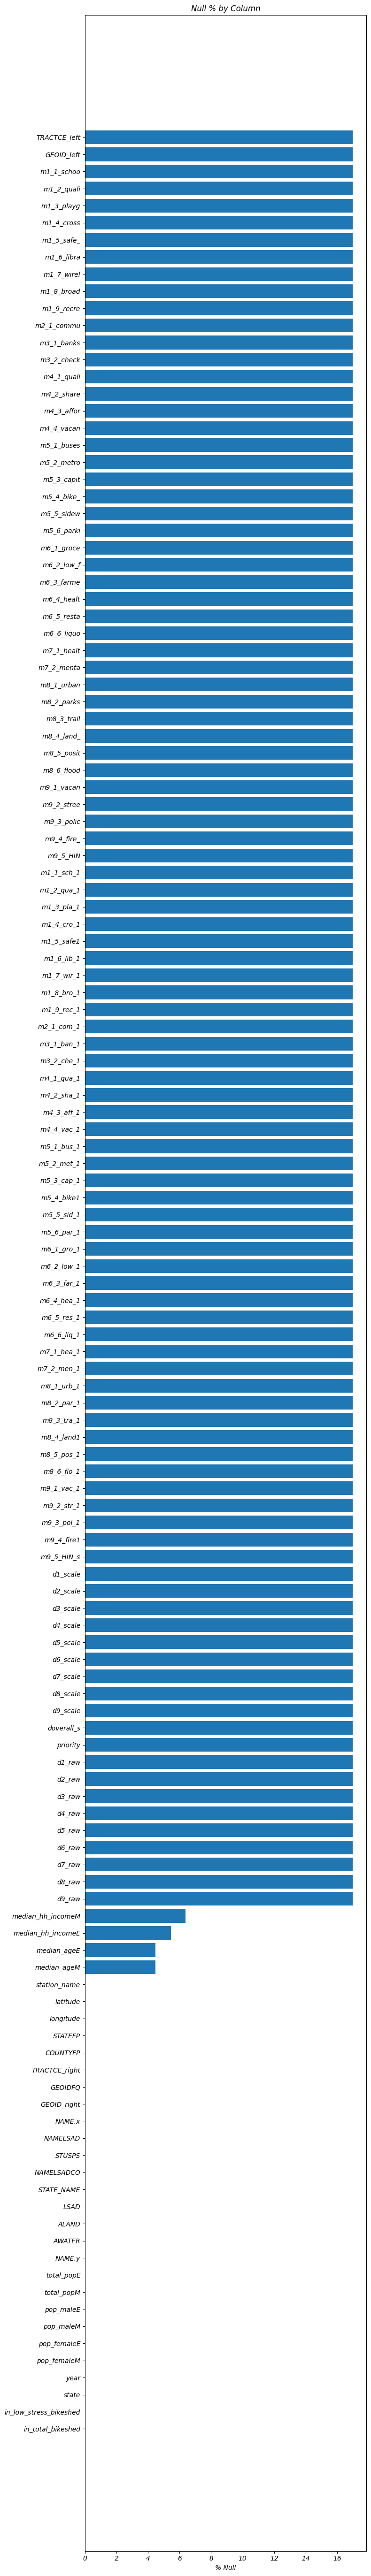

In [6]:
total_nulls = cabi.null_count()

null_pct = (
    total_nulls
    .unpivot(variable_name="column", value_name="null_count")
    .with_columns((pl.col("null_count") / cabi.height * 100).alias("null_pct"))
    .filter(pl.col("null_pct") > 0)
    .sort("null_pct", descending=True)
)

fig, ax = plt.subplots(figsize=(8, null_pct.height * 0.4 + 1))
ax.barh(null_pct["column"].to_list(), null_pct["null_pct"].to_list())
ax.set_xlabel("% Null")
ax.set_title("Null % by Column")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [7]:
# lets check affected dc stations

cabi.filter(pl.col("STATEFP") != "11").n_unique(pl.col("start_station_id"))

443

# Joining EPA data

Since the data we have doesn't cover all of our dataset lets remove the data and then add in the epa.

In [8]:
cabi

start_station_id,started_at_15,deps,arrs,demand,station_name,latitude,longitude,TRACTCE_left,GEOID_left,m1_1_schoo,m1_2_quali,m1_3_playg,m1_4_cross,m1_5_safe_,m1_6_libra,m1_7_wirel,m1_8_broad,m1_9_recre,m2_1_commu,m3_1_banks,m3_2_check,m4_1_quali,m4_2_share,m4_3_affor,m4_4_vacan,m5_1_buses,m5_2_metro,m5_3_capit,m5_4_bike_,m5_5_sidew,m5_6_parki,m6_1_groce,m6_2_low_f,m6_3_farme,m6_4_healt,m6_5_resta,…,d1_raw,d2_raw,d3_raw,d4_raw,d5_raw,d6_raw,d7_raw,d8_raw,d9_raw,STATEFP,COUNTYFP,TRACTCE_right,GEOIDFQ,GEOID_right,NAME.x,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,NAME.y,total_popE,total_popM,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,year,state,in_low_stress_bikeshed,in_total_bikeshed
f64,"datetime[μs, UTC]",i32,i32,i32,str,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,i64
22907.0,2026-01-15 17:00:00 UTC,1,1,0,"""3035 V St""",38.918767,-76.965328,"""011100""","""11001011100""",0.817486,0.0,0.360518,0.040651,0.0,0.322176,0.85939,0.808346,0.73043,0.737736,0.771276,0.381927,0.065775,0.153281,0.153771,0.817414,0.202418,0.0,0.231607,0.005958,0.993762,0.914916,0.477518,0.210532,0.060055,0.564849,0.36368,…,0.194061,0.296117,0.453883,0.551066,0.260769,0.237817,0.171117,0.443689,0.379757,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1
22907.0,2026-01-15 17:15:00 UTC,2,2,0,"""3035 V St""",38.918767,-76.965328,"""011100""","""11001011100""",0.817486,0.0,0.360518,0.040651,0.0,0.322176,0.85939,0.808346,0.73043,0.737736,0.771276,0.381927,0.065775,0.153281,0.153771,0.817414,0.202418,0.0,0.231607,0.005958,0.993762,0.914916,0.477518,0.210532,0.060055,0.564849,0.36368,…,0.194061,0.296117,0.453883,0.551066,0.260769,0.237817,0.171117,0.443689,0.379757,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1
22907.0,2026-01-15 17:45:00 UTC,2,2,0,"""3035 V St""",38.918767,-76.965328,"""011100""","""11001011100""",0.817486,0.0,0.360518,0.040651,0.0,0.322176,0.85939,0.808346,0.73043,0.737736,0.771276,0.381927,0.065775,0.153281,0.153771,0.817414,0.202418,0.0,0.231607,0.005958,0.993762,0.914916,0.477518,0.210532,0.060055,0.564849,0.36368,…,0.194061,0.296117,0.453883,0.551066,0.260769,0.237817,0.171117,0.443689,0.379757,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1
22907.0,2026-01-15 18:00:00 UTC,1,1,0,"""3035 V St""",38.918767,-76.965328,"""011100""","""11001011100""",0.817486,0.0,0.360518,0.040651,0.0,0.322176,0.85939,0.808346,0.73043,0.737736,0.771276,0.381927,0.065775,0.153281,0.153771,0.817414,0.202418,0.0,0.231607,0.005958,0.993762,0.914916,0.477518,0.210532,0.060055,0.564849,0.36368,…,0.194061,0.296117,0.453883,0.551066,0.260769,0.237817,0.171117,0.443689,0.379757,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056

In [9]:
import polars.selectors as cs 
cabi_small = cabi.drop(cs.by_index(range(8, 112))) # remmove all dc open data files
cabi_small

start_station_id,started_at_15,deps,arrs,demand,station_name,latitude,longitude,STATEFP,COUNTYFP,TRACTCE_right,GEOIDFQ,GEOID_right,NAME.x,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,NAME.y,total_popE,total_popM,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,year,state,in_low_stress_bikeshed,in_total_bikeshed
f64,"datetime[μs, UTC]",i32,i32,i32,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,i64
22907.0,2026-01-15 17:00:00 UTC,1,1,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1
22907.0,2026-01-15 17:15:00 UTC,2,2,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1
22907.0,2026-01-15 17:45:00 UTC,2,2,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1
22907.0,2026-01-15 18:00:00 UTC,1,1,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1
22907.0,2026-01-15 18:15:00 UTC,1,1,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
33204.0,2026-03-31 20:30:00 UTC,0,1,1,"""15th & Chapin St NW""",38.921468,-77.035244,"""11""","""001""","""003701""","""1400000US11001003701""","""11001003701""","""37.01""","""Census Tract 37.01""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",172840.0,0.0,"""Census Tract 37.01; District o…",2508.0,224.0,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,2024.0,"""DC""",1,1
33204.0,2026-03-31 20:45:00 UTC,0,1,1,"""15th & Chapin St NW""",38.921468,-77.035244,"""11""","""001""","""003701""","""1400000US11001003701""","""11001003701""","""37.01""","""Census Tract 37.01""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",172840.0,0.0,"""Census Tract 37.01; District o…",2508.0,224.0,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,2024.0,"""DC""",1,1
33204.0,2026-03-31 22:45:00 UTC,0,1,1,"""15th & Chapin St NW""",38.921468,-77.035244,"""11""","""001""","""003701""","""1400000US11001003701""","""11001003701""","""37.01""","""Census Tract 37.01""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",172840.0,0.0,"""Census Tract 37.01; District o…",2508.0,224.0,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,2024.0,"""DC""",1,1


## Read in epa

In [10]:
import geopandas as gpd
smart_locks = gpd.read_file(
    "C:/Users/bingo/OneDrive - Georgia Institute of Technology/CSE7643/project/SmartLocationDatabaseV3/SmartLocationDatabase.gdb",
    layer="EPA_SLD_Database_V3"
)
# reproject for lat lon
smart_locks = smart_locks.to_crs(epsg=4326)

## Extract station information

In [11]:
stations_pd = cabi_small.select(["start_station_id", "latitude", "longitude"]).unique().to_pandas()
# then convert to a spartial dataframe
stations_gdf = gpd.GeoDataFrame(
    stations_pd,
    geometry=gpd.points_from_xy(stations_pd["longitude"], stations_pd["latitude"]),
    crs="EPSG:4326"
)

## Join Together

In [12]:
smart_locks.columns.tolist()

['GEOID10',
 'GEOID20',
 'STATEFP',
 'COUNTYFP',
 'TRACTCE',
 'BLKGRPCE',
 'CSA',
 'CSA_Name',
 'CBSA',
 'CBSA_Name',
 'CBSA_POP',
 'CBSA_EMP',
 'CBSA_WRK',
 'Ac_Total',
 'Ac_Water',
 'Ac_Land',
 'Ac_Unpr',
 'TotPop',
 'CountHU',
 'HH',
 'P_WrkAge',
 'AutoOwn0',
 'Pct_AO0',
 'AutoOwn1',
 'Pct_AO1',
 'AutoOwn2p',
 'Pct_AO2p',
 'Workers',
 'R_LowWageWk',
 'R_MedWageWk',
 'R_HiWageWk',
 'R_PCTLOWWAGE',
 'TotEmp',
 'E5_Ret',
 'E5_Off',
 'E5_Ind',
 'E5_Svc',
 'E5_Ent',
 'E8_Ret',
 'E8_off',
 'E8_Ind',
 'E8_Svc',
 'E8_Ent',
 'E8_Ed',
 'E8_Hlth',
 'E8_Pub',
 'E_LowWageWk',
 'E_MedWageWk',
 'E_HiWageWk',
 'E_PctLowWage',
 'D1A',
 'D1B',
 'D1C',
 'D1C5_RET',
 'D1C5_OFF',
 'D1C5_IND',
 'D1C5_SVC',
 'D1C5_ENT',
 'D1C8_RET',
 'D1C8_OFF',
 'D1C8_IND',
 'D1C8_SVC',
 'D1C8_ENT',
 'D1C8_ED',
 'D1C8_HLTH',
 'D1C8_PUB',
 'D1D',
 'D1_FLAG',
 'D2A_JPHH',
 'D2B_E5MIX',
 'D2B_E5MIXA',
 'D2B_E8MIX',
 'D2B_E8MIXA',
 'D2A_EPHHM',
 'D2C_TRPMX1',
 'D2C_TRPMX2',
 'D2C_TRIPEQ',
 'D2R_JOBPOP',
 'D2R_WRKEMP',
 'D2A_

Below we select relevant variables including:

1. D1B: Gross population density (people/acre) on unprotected land 
2. D2B_E8MIX: 8-tier employment entropy (denominator set to observed employment types in the CBG) 
3. D3B: Street intersection density (weighted, auto-oriented intersections eliminated) 
4. D4A: Distance from the population-weighted centroid to nearest transit stop (meters) 
5. D3AMM: Network density in terms of facility miles of multi-modal links per square mile 
6. D3bmm4: Intersection density in terms of multi-modal intersections having four or more legs per square mile 
7. NatWalkInd: National Walking Index


In [13]:
smart_locks_selected = smart_locks[["GEOID10", "GEOID20", "D1B", "D2B_E8MIX", "D3B", "D4A", "D3AMM","D3BMM4","NatWalkInd", "geometry"]]

In [14]:
stations_with_smart_locks = gpd.sjoin(
    stations_gdf,
    smart_locks_selected,
    how="left",
    predicate="within"  # "within" for points-in-polygons
)

## Join back onto the data

In [15]:
# import into polars
stations_with_smart_locks_pl = pl.from_pandas(stations_with_smart_locks.drop(columns = "geometry"))

cabi_new = cabi_small.join(stations_with_smart_locks_pl, on = "start_station_id", how="left")
cabi_new

start_station_id,started_at_15,deps,arrs,demand,station_name,latitude,longitude,STATEFP,COUNTYFP,TRACTCE_right,GEOIDFQ,GEOID_right,NAME.x,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,NAME.y,total_popE,total_popM,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,year,state,in_low_stress_bikeshed,in_total_bikeshed,latitude_right,longitude_right,index_right,GEOID10,GEOID20,D1B,D2B_E8MIX,D3B,D4A,D3AMM,D3BMM4,NatWalkInd
f64,"datetime[μs, UTC]",i32,i32,i32,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,i64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64
22907.0,2026-01-15 17:00:00 UTC,1,1,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1,38.918767,-76.965328,61407.0,"""110010111001""","""110010111001""",5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667
22907.0,2026-01-15 17:15:00 UTC,2,2,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1,38.918767,-76.965328,61407.0,"""110010111001""","""110010111001""",5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667
22907.0,2026-01-15 17:45:00 UTC,2,2,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1,38.918767,-76.965328,61407.0,"""110010111001""","""110010111001""",5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667
22907.0,2026-01-15 18:00:00 UTC,1,1,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1,38.918767,-76.965328,61407.0,"""110010111001""","""110010111001""",5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667
22907.0,2026-01-15 18:15:00 UTC,1,1,0,"""3035 V St""",38.918767,-76.965328,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1,38.918767,-76.965328,61407.0,"""110010111001""","""110010111001""",5.431601,0.462678,73.626843,280.29,3.068005,12.36654,13.166667
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
33204.0,2026-03-31 20:30:00 UTC,0,1,1,"""15th & Chapin St NW""",38.921468,-77.035244,"""11""","""001""","""003701""","""1400000US11001003701""","""11001003701""","""37.01""","""Census Tract 37.01""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",172840.0,0.0,"""Census Tract 37.01; District o…",2508.0,224.0,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,2024.0,"""DC""",1,1,38.921468,-77.035244,61550.0,"""110010037003""","""110010037003""",102.323743,0.952048,1350.231831,414.41,12.036012,23.270631,14.666667
33204.0,2026-03-31 20:45:00 UTC,0,1,

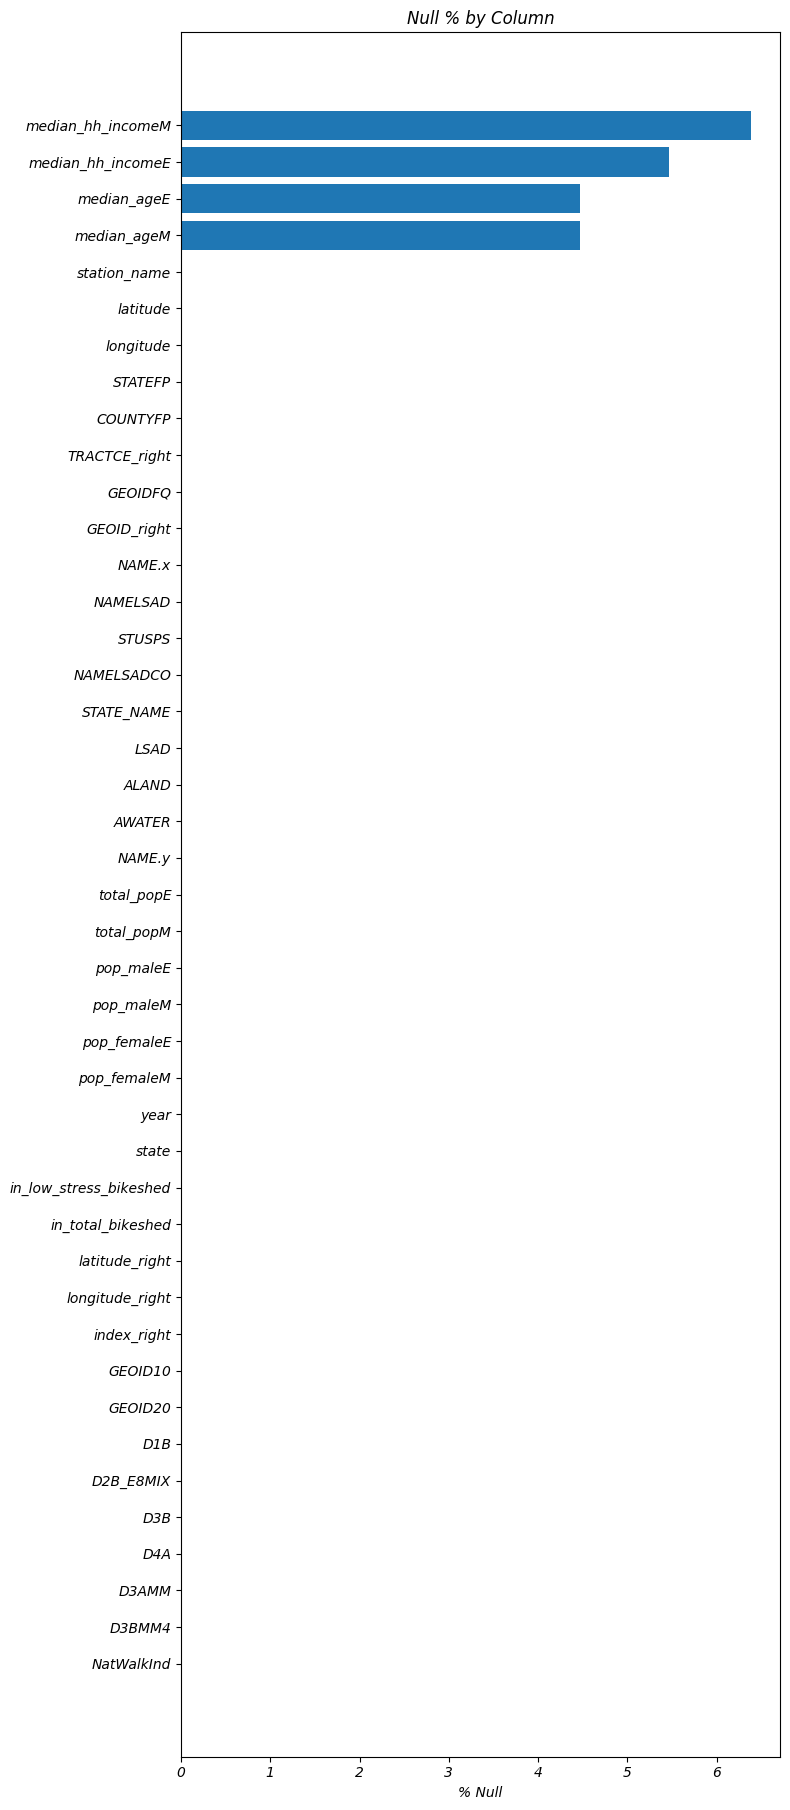

In [16]:
total_nulls = cabi_new.null_count()

null_pct = (
    total_nulls
    .unpivot(variable_name="column", value_name="null_count")
    .with_columns((pl.col("null_count") / cabi_new.height * 100).alias("null_pct"))
    .filter(pl.col("null_pct") > 0)
    .sort("null_pct", descending=True)
)

fig, ax = plt.subplots(figsize=(8, null_pct.height * 0.4 + 1))
ax.barh(null_pct["column"].to_list(), null_pct["null_pct"].to_list())
ax.set_xlabel("% Null")
ax.set_title("Null % by Column")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [17]:
total_nulls

start_station_id,started_at_15,deps,arrs,demand,station_name,latitude,longitude,STATEFP,COUNTYFP,TRACTCE_right,GEOIDFQ,GEOID_right,NAME.x,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,NAME.y,total_popE,total_popM,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,year,state,in_low_stress_bikeshed,in_total_bikeshed,latitude_right,longitude_right,index_right,GEOID10,GEOID20,D1B,D2B_E8MIX,D3B,D4A,D3AMM,D3BMM4,NatWalkInd
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,831288,831288,1018005,1189942,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8


# Fix missing data
We have 2 things to do:
1. Drop stations with no lat / lon
2. Impute the mdian income and mdeian age

## Drop null lats
We only want those that have lat and long, this is only 8 records total, so i don't mind dropping them.

In [18]:
cabi_new = cabi_new.drop_nulls(pl.col("latitude")) # drop those that don't have a lat / long (only 8 rows)

## Spatial Imputation of Missing Census
Some of the census data is missing, lets see why and where. Ideally we can just take the closest station that does have data and use that as a proxy.

In [19]:
cabi_new.null_count()

start_station_id,started_at_15,deps,arrs,demand,station_name,latitude,longitude,STATEFP,COUNTYFP,TRACTCE_right,GEOIDFQ,GEOID_right,NAME.x,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,NAME.y,total_popE,total_popM,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,year,state,in_low_stress_bikeshed,in_total_bikeshed,latitude_right,longitude_right,index_right,GEOID10,GEOID20,D1B,D2B_E8MIX,D3B,D4A,D3AMM,D3BMM4,NatWalkInd
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,831280,831280,1017997,1189934,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [20]:
cabi_new.filter(pl.col("median_ageE").is_null()
    ).select(["start_station_id", "station_name", "STATEFP", "COUNTYFP"]).unique()

start_station_id,station_name,STATEFP,COUNTYFP
f64,str,str,str
31240.0,"""Ohio Dr & West Basin Dr SW / M…","""11""","""001"""
31321.0,"""15th St & Constitution Ave NW""","""11""","""001"""
31219.0,"""10th St & Constitution Ave NW""","""11""","""001"""
31292.0,"""22nd St & Constitution Ave NW""","""11""","""001"""
31935.0,"""National Airport""","""51""","""013"""
…,…,…,…
31248.0,"""Smithsonian-National Mall / Je…","""11""","""001"""
31211.0,"""Kennedy Center""","""11""","""001"""
31261.0,"""21st St & Constitution Ave NW""","""11""","""001"""


It looks like these are all in DC around some areas around 2 county codes in DC. This seems to be federally owned land specifically.

In [23]:
# Split into complete and incomplete

incomplete = cabi_new.filter(pl.col("median_hh_incomeE").is_null())

impute_cols = ["median_ageE", "median_ageM", "median_hh_incomeE", "median_hh_incomeM"]
# get the complete columns
complete = cabi_new.filter(
    pl.all_horizontal([pl.col(c).is_not_null() for c in impute_cols])
)

# Cross join to get all pairwise distances
nearest = (
    incomplete.select(["station_name", "latitude", "longitude"]).unique()
    .join(
        complete.select(["station_name", "latitude", "longitude"] + impute_cols).unique(),
        how="cross"
    )
    # use the euclidean distance here
    .with_columns(
        (
            (pl.col("latitude") - pl.col("latitude_right")).pow(2) +
            (pl.col("longitude") - pl.col("longitude_right")).pow(2)
        ).sqrt().alias("dist")
    )
    .sort("dist")
    .group_by("station_name") 
    .first()  # nearest neighbor per null station
    .select(["station_name"] + impute_cols)
)

# Join imputed values back
cabi_imputed = (
    cabi_new.join(nearest, on="station_name", how="left", suffix="_imputed")
    .with_columns([
        pl.coalesce([pl.col(c), pl.col(f"{c}_imputed")]).alias(c)
        for c in impute_cols
    ])
    .drop([f"{c}_imputed" for c in impute_cols])
)


In [ ]:
cabi_imputed.describe()

statistic,start_station_id,started_at_15,deps,arrs,demand,station_name,latitude,longitude,STATEFP,COUNTYFP,TRACTCE_right,GEOIDFQ,GEOID_right,NAME.x,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,NAME.y,total_popE,total_popM,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,year,state,in_low_stress_bikeshed,in_total_bikeshed,latitude_right,longitude_right,index_right,GEOID10,GEOID20,D1B,D2B_E8MIX,D3B,D4A,D3AMM,D3BMM4,NatWalkInd
str,f64,str,f64,f64,f64,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64
"""count""",1.8621383e7,"""18621383""",1.8621383e7,1.8621383e7,1.8621383e7,"""18621383""",1.8621383e7,1.8621383e7,"""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""","""18621383""",1.8621383e7,1.8621383e7,"""18621383""",1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.8449446e7,1.8621383e7,"""18621383""",1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,"""18621383""","""18621383""",1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7,1.8621383e7
"""null_count""",0.0,"""0""",0.0,0.0,0.0,"""0""",0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,171937.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",31406.154005,"""2024-04-12 01:10:31.492328+00:…",0.983769,0.975595,-0.008174,null,38.903591,-77.034744,null,null,null,null,null,null,null,null,null,null,null,870288.276693,227458.289452,null,3160.266509,467.246182,1529.71012,297.80524,1630.556389,323.90588,34.97634,3.206372,133682.717773,32695.288234,2024.0,null,0.95035,0.992544,38.903591,-77.034744,57012.550841,null,null,33.861057,0.656553,202.942104,-443.535693,9.269114,37.497619,16.061811
"""std""",332.001769,null,1.119009,1.12537,1.566444,null,0.030651,0.040627,null,null,null,null,null,null,null,null,null,null,null,1.3233e6,974263.496184,null,1401.853708,198.237465,681.870369,126.215877,774.688154,143.103965,6.288563,1.964558,44908.093706,17891.755717,0.0,null,0.21722,0.086023,0.030651,0.040627,17552.627386,null,null,26.473224,0.15176,122.893707,8162.022767,6.450091,28.984128,1.991996
"""min""",22907.0,"""2022-01-01 00:00:00+00:00""",0.0,0.0,-33.0,""" Scotts Crossing Rd & Spring G…",38.766844,-77.419355,"""11""","""001""","""000102""","""1400000US11001000102""","""11001000102""","""1.02""","""Census Tract 1.02""","""DC""","""Alexandria city""","""District of Columbia""","""CT""",93419.0,0.0,"""Census Tract 1.02; District of…",0.0,13.0,0.0,13.0,0.0,13.0,19.5,0.3,12117.0,1403.0,2024.0,"""DC""",0.0,0.0,38.766844,-77.419355,15952.0,"""110010001001""","""110010001001""",0.005408,0.0,0.0,-99999.0,0.0,0.0,4.333333
"""25%""",31210.0,"""2023-05-03 11:00:00+00:00""",0.0,0.0,-1.0,null,38.890461,-77.048043,null,null,null,null,null,null,null,null,null,null,null,263878.0,0.0,null,2417.0,354.0,1095.0,228.0,1151.0,237.0,31.9,1.9,105000.0,20931.0,2024.0,null,1.0,1.0,38.890461,-77.048043,61417.0,null,null,13.598225,0.561932,139.858716,140.82,4.78653,12.673446,14.833333
"""50%""",31298.0,"""2024-05-22 08:30:00+00:00""",1.0,1.0,0.0,null,38.902826,-77.031887,null,null,null,null,null,null,null,null,null,null,null,494704.0,0.0,null,3003.0,451.0,1475.0,278.0,1548.0,324.0,34.5,2.8,132809.0,28202.0,2024.0,null,1.0,1.0,38.902826,-77.031887,61593.0,null,null,23.894368,0.676256,184.375562,209.21,8.414852,34.948061,16.166667
"""75%""",31620.0,"""2025-04-28 22:15:00+00:00""",1.0,1.0,1.0,null,38.916804,-77.012108,null,null,null,null,null,null,null,null,null,null,null,889722.0,0.0,null,3823.0,558.0,1907.0,358.0,1986.0,402.0,37.4,4.0,163036.0,41094.0,2024.0,null,1.0,1.0,38.916804,-77.012108,61705.0,null,null,49.7872

# Write out
Lets write out the imputed column

In [27]:
cabi_imputed.write_parquet("C:/Users/bingo/OneDrive - Georgia Institute of Technology/CSE7643/project/cabi_demand_imputed_master.parquet")